In [37]:
import struct
import numpy as np
from scipy.signal import hilbert
from scipy.stats import linregress
import matplotlib.pyplot as plt
import os

In [38]:
#Change this for each TMM
RF_FILE = '/Users/taliacho/Downloads/Ranger/Bryan-Ranger-1/attenuation_coef/ballistic/2026-01-16T23-37-04+0000_rf.raw'
 
FS = 60e6      # sampling rate (Hz)
FC  = 16e6      # transmit frequency (Hz)
SPEED_SOUND = 1540      # speed of sound in tissue (m/s)
DELAY_SAMPLES = 24        # samples before tissue starts (from rf.yml)
 
NEAR_FIELD_CUTOFF_MM = 0.5  # exclude near-field ring-down artefact below this depth
 
# TGC control points from tgc.yml (averaged across 4 frames)
TGC_DEPTHS_MM = np.array([2.0,   6.0,   10.0 ])
TGC_GAINS_DB  = np.mean([
    [13.39, 19.97, 26.92],   # frame 0
    [13.39, 19.97, 26.92],   # frame 1
    [13.39, 19.97, 26.92],   # frame 2
    [13.59, 20.72, 27.98],   # frame 3
], axis=0)

In [39]:
def read_raw(file_path):
    """
    Read a Clarius .raw RF file.
 
    File structure:
        Header  : [uint32 id, uint32 numFrames, uint32 numScanLines,
                   uint32 numSamplesPerLine, uint32 sampleSizeInBytes]  — 20 bytes
        Per frame: [uint64 timestamp]  +  [int16 samples: numScanLines × numSamplesPerLine]
 
    Returns
    -------
    header     : dict
    timestamps : np.ndarray, shape (numFrames,), dtype uint64
    rf_data    : np.ndarray, shape (numFrames, numScanLines, numSamplesPerLine), dtype int16
    """
    header_format = '<5I'                          # 5 × uint32, little-endian
    header_size   = struct.calcsize(header_format) # 20 bytes
 
    timestamp_format = '<Q'                        # uint64, little-endian
    timestamp_size   = struct.calcsize(timestamp_format)  # 8 bytes
 
    with open(file_path, 'rb') as f:
        raw_header = f.read(header_size)
        id_, num_frames, num_lines, num_samples, sample_size = struct.unpack(header_format, raw_header)
 
        header = {
            'id'               : id_,
            'numFrames'        : num_frames,
            'numScanLines'     : num_lines,
            'numSamplesPerLine': num_samples,
            'sampleSizeInBytes': sample_size,
        }
 
        assert sample_size == 2, f'Expected 2-byte int16 RF samples, got {sample_size}'
 
        frame_data_bytes = num_lines * num_samples * sample_size
 
        timestamps = np.zeros(num_frames, dtype=np.uint64)
        rf_data    = np.zeros((num_frames, num_lines, num_samples), dtype=np.int16)
 
        for i in range(num_frames):
            ts_raw        = f.read(timestamp_size)
            timestamps[i] = struct.unpack(timestamp_format, ts_raw)[0]
 
            frame_raw  = f.read(frame_data_bytes)
            frame_arr  = np.frombuffer(frame_raw, dtype=np.int16)
            rf_data[i] = frame_arr.reshape(num_lines, num_samples)
 
    return header, timestamps, rf_data

In [40]:
def build_depth_axis(num_samples, delay_samples, fs, speed_sound):
    """
    Convert sample indices to physical depth in mm.
 
    Each sample represents one round-trip travel time of 1/fs seconds.
    One-way depth = time × (c/2).
 
    Parameters
    ----------
    num_samples   : total samples per line (e.g. 336)
    delay_samples : samples before tissue (from rf.yml, e.g. 24)
    fs            : sampling rate in Hz
    speed_sound   : speed of sound in m/s
 
    Returns
    -------
    depth_mm_axis : np.ndarray, depths in mm for each tissue sample
    sample_indices: np.ndarray, corresponding sample indices
    """
    depth_per_sample_mm = (1 / fs) * (speed_sound / 2) * 1e3  # mm per sample
 
    sample_indices = np.arange(delay_samples, num_samples)
    depth_mm_axis  = (sample_indices - delay_samples) * depth_per_sample_mm
 
    return depth_mm_axis, sample_indices

In [41]:
def compute_envelope(rf_data, delay_samples):
    """
    Compute the amplitude envelope of the RF signal using the Hilbert transform,
    then average across all frames and scan lines to reduce speckle.
 
    The Hilbert transform converts the oscillating RF signal into a smooth
    amplitude (envelope) curve. Averaging across many lines and frames
    further reduces random speckle noise.
 
    Parameters
    ----------
    rf_data       : np.ndarray, shape (frames, lines, samples), dtype int16
    delay_samples : number of samples to skip (pre-tissue delay)
 
    Returns
    -------
    env_avg_tissue : 1D np.ndarray — mean envelope, cropped to tissue region
    """
    rf_float = rf_data.astype(np.float64)
 
    # Hilbert transform along the samples (depth) axis
    envelope = np.abs(hilbert(rf_float, axis=2))  # shape: (frames, lines, samples)
 
    # Average across all frames and all scan lines → one curve vs depth
    env_avg = np.mean(envelope, axis=(0, 1))       # shape: (samples,)
 
    # Crop to tissue region (discard delay samples)
    env_avg_tissue = env_avg[delay_samples:]
 
    return env_avg_tissue

In [42]:
def compensate_tgc(env_db, depth_mm_axis, tgc_depths_mm, tgc_gains_db):
    """
    Remove the Time Gain Compensation (TGC) that the probe applied.
 
    The probe artificially amplifies deeper echoes to make the image look
    uniform. To measure true attenuation, we must subtract this added gain.
    TGC is given as sparse control points and interpolated to every depth.
 
    Parameters
    ----------
    env_db        : 1D array, envelope in dB vs depth
    depth_mm_axis : 1D array, depth in mm for each sample
    tgc_depths_mm : control point depths from tgc.yml
    tgc_gains_db  : control point gains from tgc.yml
 
    Returns
    -------
    env_corrected_db : envelope in dB with TGC removed
    tgc_interp       : interpolated TGC curve (for plotting)
    """
    # Interpolate TGC at every depth sample; clamp at boundaries
    tgc_interp = np.interp(depth_mm_axis, tgc_depths_mm, tgc_gains_db,
                           left=tgc_gains_db[0], right=tgc_gains_db[-1])
 
    env_corrected_db = env_db - tgc_interp
 
    return env_corrected_db, tgc_interp

In [43]:
def calculate_attenuation(env_corrected_db, depth_mm_axis, fc,
                           near_field_cutoff_mm=0.5):
    """
    Fit a line to the TGC-corrected envelope vs depth and extract α.
 
    After TGC correction, the signal decays linearly in dB due to attenuation:
        envelope_dB(z) = A - 2·α·f·z·log10(e)·... → linear in z
 
    The slope of the fit (dB/mm) gives α via:
        α = -slope × 10 / (2 × fc_MHz)     [dB/cm/MHz]
 
    The factor of 2 accounts for the round trip (pulse travels down AND back).
    The ×10 converts dB/mm → dB/cm.
 
    Parameters
    ----------
    env_corrected_db     : 1D array, TGC-corrected envelope in dB
    depth_mm_axis        : 1D array, depth in mm
    fc                   : transmit frequency in Hz
    near_field_cutoff_mm : exclude samples shallower than this (ring-down artefact)
 
    Returns
    -------
    alpha   : attenuation coefficient in dB/cm/MHz
    slope   : linear fit slope in dB/mm
    r_sq    : R² of the fit
    fit_result : dict with fit details for plotting
    """
    mask       = depth_mm_axis >= near_field_cutoff_mm
    depth_fit  = depth_mm_axis[mask]
    env_fit    = env_corrected_db[mask]
 
    slope, intercept, r, p, se = linregress(depth_fit, env_fit)
 
    # α = -slope [dB/mm] × 10 [mm/cm] / (2 × fc [MHz])
    alpha = -slope * 10 / (2 * (fc / 1e6))
    r_sq  = r ** 2
 
    fit_result = {
        'slope'    : slope,
        'intercept': intercept,
        'r_sq'     : r_sq,
        'depth_fit': depth_fit,
        'fit_line' : slope * depth_fit + intercept,
    }
 
    return alpha, slope, r_sq, fit_result

In [44]:
def plot_results(depth_mm_axis, env_db, env_corrected_db, tgc_interp,
                 fit_result, alpha, fc, fs, delay_samples,
                 num_frames, num_lines, near_field_cutoff_mm,
                 output_folder='.'):  
 
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
    # Panel 1: Raw envelope in dB
    axes[0].plot(depth_mm_axis, env_db, color='steelblue', linewidth=1.5)
    axes[0].set_xlabel('Depth (mm)')
    axes[0].set_ylabel('Amplitude (dB)')
    axes[0].set_title('Mean Envelope (raw dB)\naveraged over all lines & frames')
    axes[0].grid(alpha=0.3)
 
    # Panel 2: TGC-corrected + linear fit
    axes[1].plot(depth_mm_axis, env_corrected_db, color='steelblue',
                 linewidth=1.5, label='TGC-corrected')
    axes[1].plot(fit_result['depth_fit'], fit_result['fit_line'],
                 'r--', linewidth=2,
                 label=f"Linear fit\nslope = {fit_result['slope']:.3f} dB/mm\n"
                       f"R² = {fit_result['r_sq']:.3f}")
    axes[1].axvspan(0, near_field_cutoff_mm, alpha=0.15, color='gray',
                    label=f'Near-field excluded\n(<{near_field_cutoff_mm} mm)')
    axes[1].set_xlabel('Depth (mm)')
    axes[1].set_ylabel('Amplitude (dB)')
    axes[1].set_title('TGC-Compensated Envelope + Linear Fit')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
 
    # Panel 3: Result summary
    axes[2].axis('off')
    axes[2].text(0.5, 0.65, f'α = {alpha:.3f} dB/cm/MHz',
                 ha='center', va='center', fontsize=28, fontweight='bold',
                 transform=axes[2].transAxes, color='#1a1a2e')
    axes[2].text(0.5, 0.38,
                 f'Probe: HD3  |  fₜₓ = {fc/1e6:.0f} MHz\n'
                 f'fs = {fs/1e6:.0f} MHz  |  delay = {delay_samples} samples\n'
                 f'Fit depth: {fit_result["depth_fit"][0]:.1f}–{fit_result["depth_fit"][-1]:.1f} mm\n'
                 f'R² = {fit_result["r_sq"]:.4f}  |  slope = {fit_result["slope"]:.4f} dB/mm\n'
                 f'Averaged over {num_frames} frames × {num_lines} scan lines',
                 ha='center', va='center', fontsize=10,
                 transform=axes[2].transAxes, color='gray')
    axes[2].set_title('Result', fontsize=13)
 
    plt.suptitle('Ultrasound Attenuation Coefficient — Clarius HD3', fontsize=13, y=1.01)
    plt.tight_layout()
    save_path = os.path.join(output_folder, 'attenuation_coefficient.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved to {save_path}')

Reading RF data...
  RF shape: (2, 152, 384)  (frames × lines × samples)
  Depth range: 0 → 4.61 mm
Computing envelope...
Compensating TGC...
Fitting attenuation...

  Slope : -2.2195 dB/mm
  R²    : 0.2215

>>> Attenuation coefficient: 0.694 dB/cm/MHz <<<



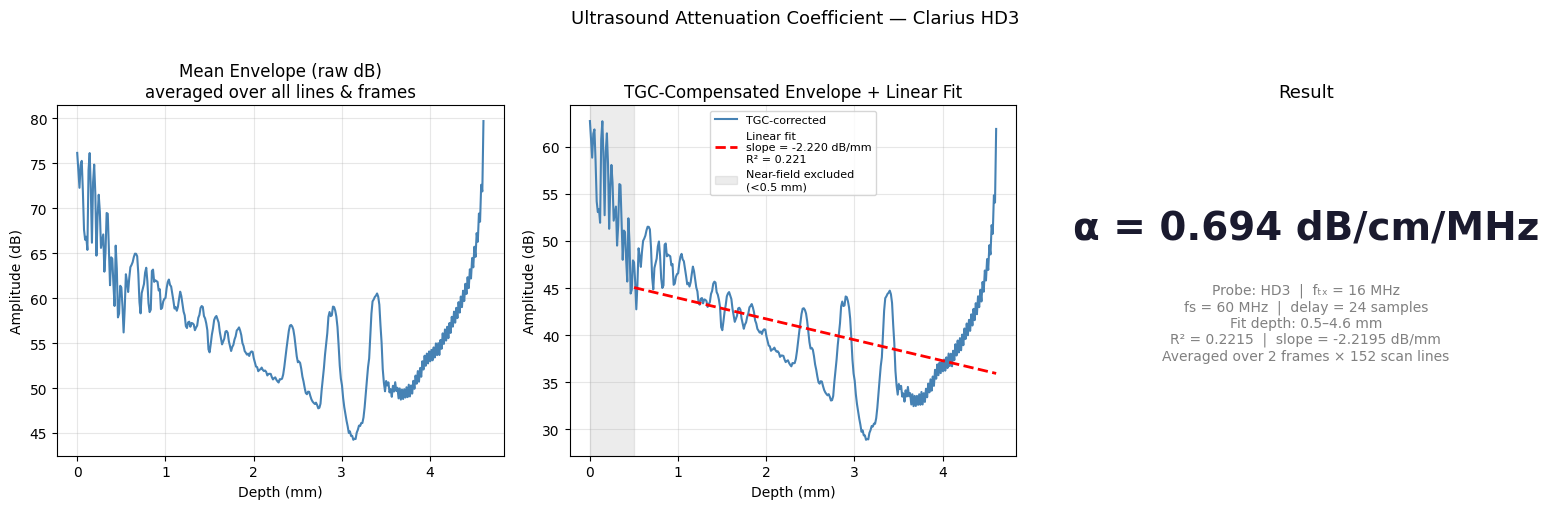

Plot saved to /Users/taliacho/Downloads/Ranger/Bryan-Ranger-1/attenuation_coef/ballistic/attenuation_coefficient.png


In [45]:
if __name__ == '__main__':
    OUTPUT_FOLDER = '/Users/taliacho/Downloads/Ranger/Bryan-Ranger-1/attenuation_coef/ballistic'  #MOFIDY
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # 1. Read file
    print('Reading RF data...')
    header, timestamps, rf_data = read_raw(RF_FILE)
    nf = header['numFrames']
    nl = header['numScanLines']
    ns = header['numSamplesPerLine']
    print(f'  RF shape: {rf_data.shape}  (frames × lines × samples)')

    # 2. Depth axis
    depth_mm_axis, _ = build_depth_axis(ns, DELAY_SAMPLES, FS, SPEED_SOUND)
    print(f'  Depth range: 0 → {depth_mm_axis[-1]:.2f} mm')

    # 3. Envelope
    print('Computing envelope...')
    env_tissue = compute_envelope(rf_data, DELAY_SAMPLES)
    eps    = np.finfo(np.float64).eps
    env_db = 20.0 * np.log10(env_tissue + eps)

    # 4. TGC compensation
    print('Compensating TGC...')
    env_corrected_db, tgc_interp = compensate_tgc(
        env_db, depth_mm_axis, TGC_DEPTHS_MM, TGC_GAINS_DB
    )

    # 5. Attenuation coefficient
    print('Fitting attenuation...')
    alpha, slope, r_sq, fit_result = calculate_attenuation(
        env_corrected_db, depth_mm_axis, FC,
        near_field_cutoff_mm=NEAR_FIELD_CUTOFF_MM
    )

    print(f'\n  Slope : {slope:.4f} dB/mm')
    print(f'  R²    : {r_sq:.4f}')
    print(f'\n>>> Attenuation coefficient: {alpha:.3f} dB/cm/MHz <<<\n')

    # 6. Plot
    plot_results(depth_mm_axis, env_db, env_corrected_db, tgc_interp,
                 fit_result, alpha, FC, FS, DELAY_SAMPLES,
                 nf, nl, NEAR_FIELD_CUTOFF_MM,
                 output_folder=OUTPUT_FOLDER)           